# Clasificador de sentimientos en reseñas sobre computadoras

#### Proceso para el entrenamiento del modelo
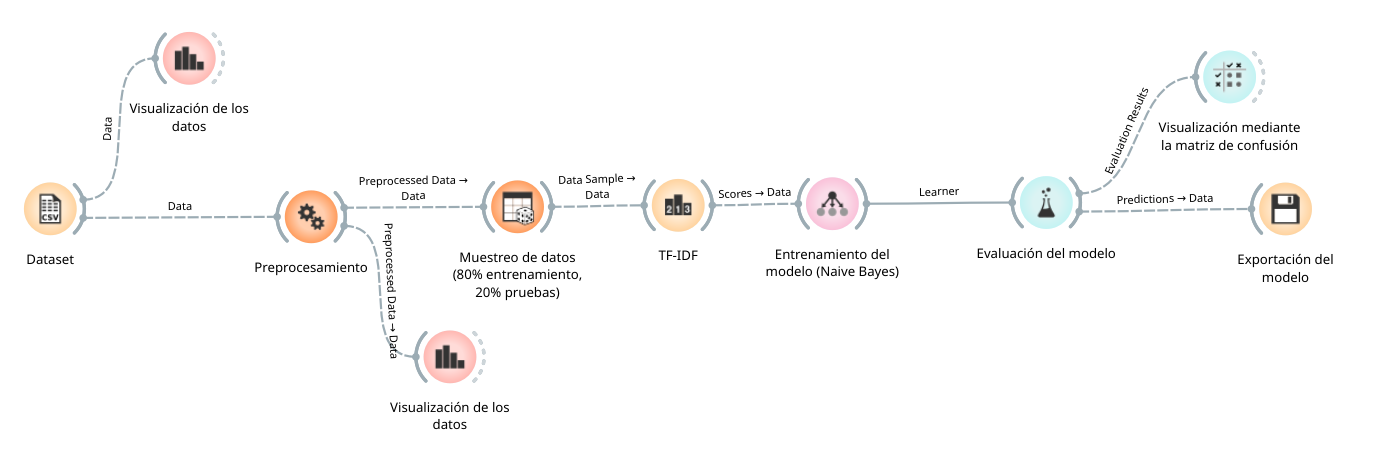

### Librerías


In [ ]:
!pip install scikit-learn nltk --quiet

#Importamos las librerías necesarias
import re
import pickle
import unicodedata
import nltk
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from nltk.corpus import stopwords
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from google.colab import files

sns.set_theme(style='whitegrid')
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

### Importación de dataset


In [ ]:
uploaded = files.upload()

#Se obtiene el archivo y se convierte en un DataFrame
filename = list(uploaded.keys())[0]
df = pd.read_csv(filename)

#Se muestra algo de información del dataset
print(f'Archivo cargado: {filename}')
print(f'Total reseñas:   {len(df)}')
print(f'Distribución:    {dict(df["etiqueta"].value_counts())}')

#Validaciones
assert 'texto' in df.columns and 'etiqueta' in df.columns
assert set(df['etiqueta'].unique()) == {'positivo', 'negativo', 'neutral'}

#Se extraen listas de textos y etiquetas para usarlas en el modelo
textos    = df['texto'].tolist()
etiquetas = df['etiqueta'].tolist()

Saving dataset.csv to dataset (3).csv
Archivo cargado: dataset (3).csv
Total reseñas:   900
Distribución:    {'positivo': np.int64(300), 'neutral': np.int64(300), 'negativo': np.int64(300)}


### Visualización 1: Distribución de clases

/tmp/ipykernel_3491/2591549681.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='etiqueta', data=df, palette='viridis',


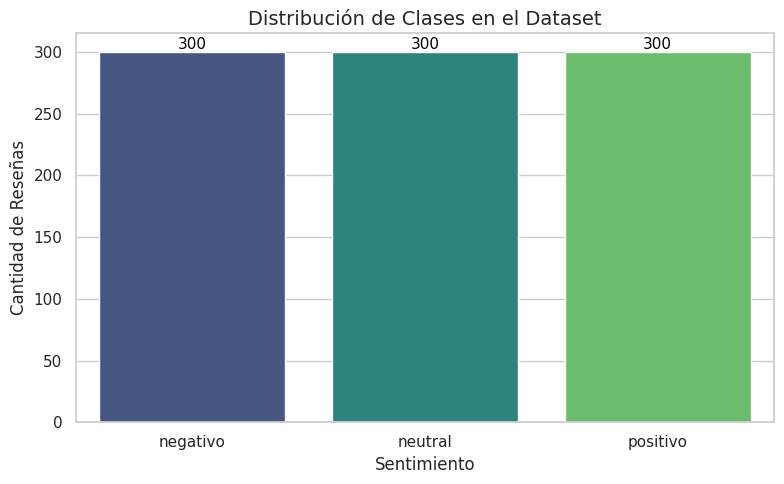

In [ ]:
#Definimos la tabla
plt.figure(figsize=(8, 5))
ax = sns.countplot(x='etiqueta', data=df, palette='viridis',
                   order=['negativo', 'neutral', 'positivo'])


#Le ponemos texto para que se sepa que es cada eje y un título
plt.title('Distribución de Clases en el Dataset', fontsize=14)
plt.xlabel('Sentimiento', fontsize=12)
plt.ylabel('Cantidad de Reseñas', fontsize=12)

#Se pone el número de reseñas arriba de cada barra
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=11, color='black',
                xytext=(0, 5), textcoords='offset points')

#Se ajusta el diseño
plt.tight_layout()
plt.show()

### Preprocesamiento

In [ ]:
#Se definen stopwords y se conservan palabras de na+egación
STOP_WORDS = set(stopwords.words('spanish')) - {
    'no','ni','nunca','jamás','tampoco','sin','nada','nadie',
    'ningún','ninguno','ninguna'
}
#Las de aquí no indican negación
PALABRAS_NEG = {'no','ni','nunca','jamas','tampoco','sin','nada'}

#Se normalizan los textos con esta función
def normalizar(text):
    return ''.join(
        c for c in unicodedata.normalize('NFD', text)
        if unicodedata.category(c) != 'Mn'
    )

#Si aparece una palabra de negación, las 3 palabras después se marcan con NEG_
def manejar_negaciones(tokens):
    resultado, n = [], 0
    for tok in tokens:
        if tok in PALABRAS_NEG:
            resultado.append(tok); n = 3
        elif n > 0:
            resultado.append('NEG_' + tok); n -= 1
        else:
            resultado.append(tok)
    return resultado

#Preprocesamiento de palabras
def preprocess(text: str) -> str:
    text = normalizar(text.lower())
    text = re.sub(r'[^\w\s]', '', text)
    tokens = [t for t in text.split() if t not in STOP_WORDS]
    tokens = manejar_negaciones(tokens)
    return ' '.join(tokens)

#Pruebas
ejemplos = [
    '¡Excelente teléfono! La cámara es increíble.',
    'No funciona como dice la descripción, muy decepcionante.',
    'Nunca más compro aquí, pésimo servicio.',
]
for e in ejemplos:
    print(f' -> {preprocess(e)}')

#Validaciones
assert 'NEG_funciona' in preprocess('No funciona bien')
assert 'camara' in preprocess('La cámara es increíble')
print('Preprocesador funcionando')

 -> excelente telefono camara increible
 -> no NEG_funciona NEG_dice NEG_descripcion decepcionante
 -> nunca NEG_mas NEG_compro NEG_aqui pesimo servicio
Preprocesador funcionando


### Visualización 2: Longitud de reseñas por clase

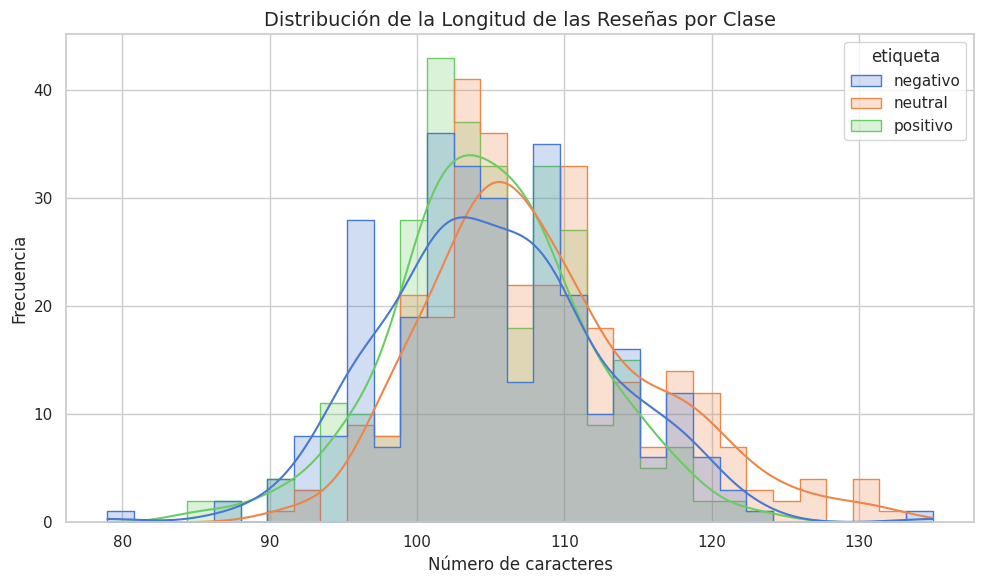

In [ ]:
#Se calcula cuanto mide cada reseña y se guarda en una columna
df['longitud'] = df['texto'].apply(len)
#Tamaño de la figura
plt.figure(figsize=(10, 6))
#Se grafica la distribución
sns.histplot(data=df, x='longitud', hue='etiqueta', kde=True,
             element='step', palette='muted',
             hue_order=['negativo', 'neutral', 'positivo'])
#Títulos y etiquetas
plt.title('Distribución de la Longitud de las Reseñas por Clase', fontsize=14)
plt.xlabel('Número de caracteres', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)
#Se ajustan los elementos
plt.tight_layout()
plt.show()

### Visualización 3: Palabras más frecuentes por clase

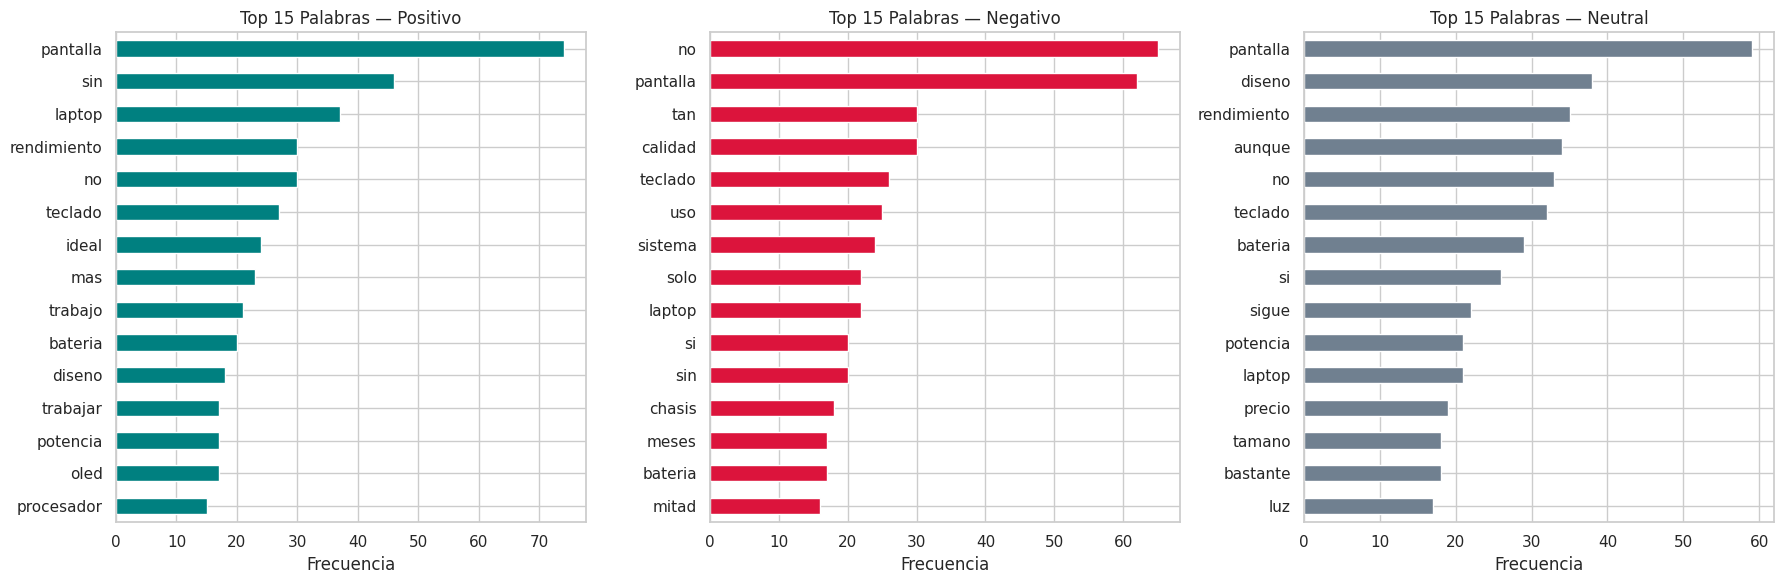

In [ ]:
#Visualización de palabras más frecuentes
def plot_top_words(texts, title, color):
    vectorizer = CountVectorizer(max_features=15)
    processed = [preprocess(t) for t in texts]
    matrix = vectorizer.fit_transform(processed)

    #Se crea un DataFrame con las frecuencias de cada palabra
    freq = pd.DataFrame(
        matrix.sum(axis=0).T,
        index=vectorizer.get_feature_names_out(),
        columns=['frecuencia']
    )
    #Se oredenan las palabras en barras horizontales
    freq.sort_values('frecuencia', ascending=True).plot(
        kind='barh', color=color, legend=None, ax=plt.gca()
    )
    plt.title(title, fontsize=12)
    plt.xlabel('Frecuencia')

#Se generan 3 gráficas
plt.figure(figsize=(18, 6))
#Mejores palabras en reseñas positivas
plt.subplot(1, 3, 1)
plot_top_words(df[df['etiqueta']=='positivo']['texto'],
               'Top 15 Palabras — Positivo', 'teal')
#Mejores palabras en reseñas negativas
plt.subplot(1, 3, 2)
plot_top_words(df[df['etiqueta']=='negativo']['texto'],
               'Top 15 Palabras — Negativo', 'crimson')
#Mejores palabras en reseñas neutrales
plt.subplot(1, 3, 3)
plot_top_words(df[df['etiqueta']=='neutral']['texto'],
               'Top 15 Palabras — Neutral', 'slategray')
plt.tight_layout()
plt.show()

### Muestreo de los datos

In [ ]:
#Preprocesamiento de todos los textos
textos_proc = [preprocess(t) for t in textos]

#Se dividen en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    textos_proc, etiquetas,
    test_size=0.20, random_state=42, stratify=etiquetas
)

#Información sobre la división
print(f'Train: {len(X_train)} muestras → {dict(Counter(y_train))}')
print(f'Test:  {len(X_test)}  muestras → {dict(Counter(y_test))}')

Train: 720 muestras → {'positivo': 240, 'neutral': 240, 'negativo': 240}
Test:  180  muestras → {'negativo': 60, 'neutral': 60, 'positivo': 60}


### TF-IDF + entrenamiendo del modelo con Naive Bayes

In [ ]:
#Entrenamiento con pipeline
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(ngram_range=(1, 1), sublinear_tf=True, min_df=2)),
    ('clf',   MultinomialNB(alpha=1.0)),
])
#Datos de entrenamiento
pipeline.fit(X_train, y_train)

#Validación cruzada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(pipeline, textos_proc, etiquetas, cv=cv, scoring='accuracy')

#Se muestran los resultados
print(f'CV 5-fold: {cv_scores.mean():.2%} ±{cv_scores.std():.2%}')
print('Entrenamiento completado')

CV 5-fold: 86.78% ±2.69%
Entrenamiento completado


### Visualización 4: Métricas y confianza del modelo

Accuracy en test (20%): 87.78%

Reporte de clasificación:
              precision    recall  f1-score   support

    negativo       0.95      0.93      0.94        60
     neutral       0.82      0.85      0.84        60
    positivo       0.86      0.85      0.86        60

    accuracy                           0.88       180
   macro avg       0.88      0.88      0.88       180
weighted avg       0.88      0.88      0.88       180



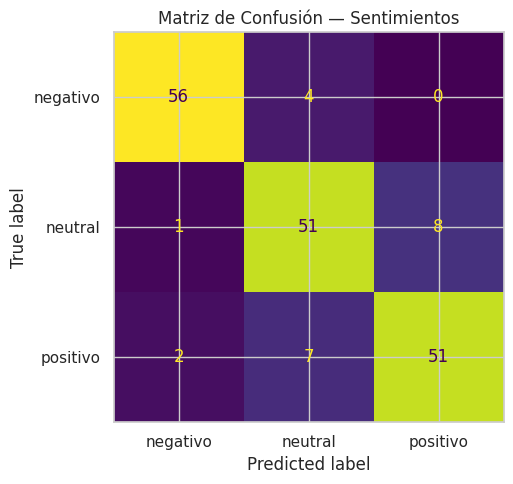

In [ ]:
#Se generan predicciones sobre las pruebas y se calcula la precisión
y_pred = pipeline.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print(f'Accuracy en test (20%): {acc:.2%}')
print('\nReporte de clasificación:')
print(classification_report(y_test, y_pred,
      target_names=['negativo', 'neutral', 'positivo']))

#Se genera la matriz de confusión
cm = confusion_matrix(y_test, y_pred, labels=['negativo', 'neutral', 'positivo'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
       display_labels=['negativo', 'neutral', 'positivo'])
#Se configura yse muestra la matriz
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, colorbar=False)
ax.set_title('Matriz de Confusión — Sentimientos')
plt.tight_layout()
plt.show()

## Evaluación del modelo

#### Heatmap de matriz de confusión

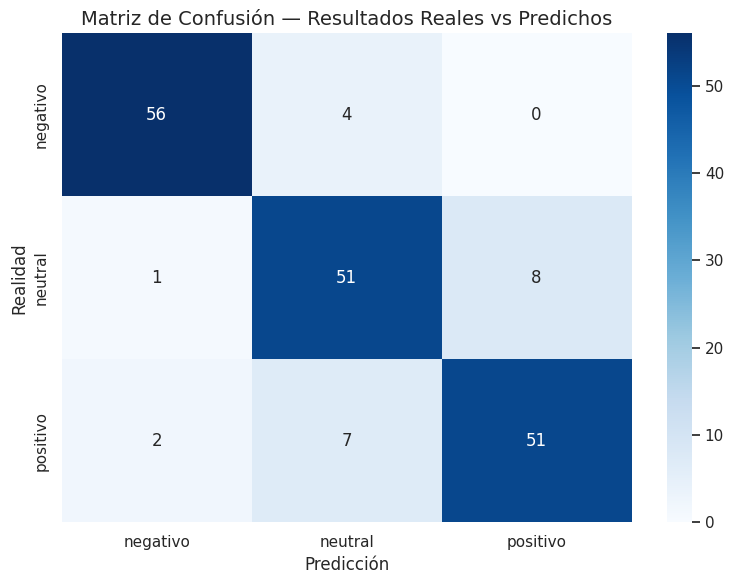

In [ ]:
#Cálculo de la matriz de confusión
cm = confusion_matrix(y_test, y_pred, labels=['negativo', 'neutral', 'positivo'])
plt.figure(figsize=(8, 6))
#Se dibuja el mapa de calor con los valores
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['negativo', 'neutral', 'positivo'],
            yticklabels=['negativo', 'neutral', 'positivo'])
plt.title('Matriz de Confusión — Resultados Reales vs Predichos', fontsize=14)
plt.xlabel('Predicción', fontsize=12)
plt.ylabel('Realidad', fontsize=12)
plt.tight_layout()
plt.show()

#### Métricas por clase

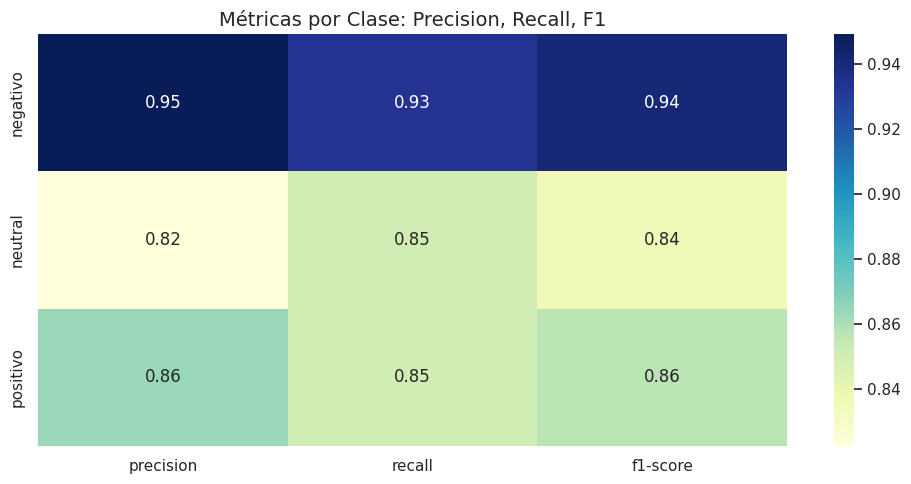

In [ ]:
#Se genera el reporte de clasificación
report = classification_report(
    y_test, y_pred,
    target_names=['negativo', 'neutral', 'positivo'],
    output_dict=True
)
#Se configura el tamaño de la figura
plt.figure(figsize=(10, 5))
sns.heatmap(
    pd.DataFrame(report).iloc[:-1, :3].T,
    annot=True, cmap='YlGnBu', fmt='.2f'
)
plt.title('Métricas por Clase: Precision, Recall, F1', fontsize=14)
plt.tight_layout()
plt.show()

#### Distribución de confianza

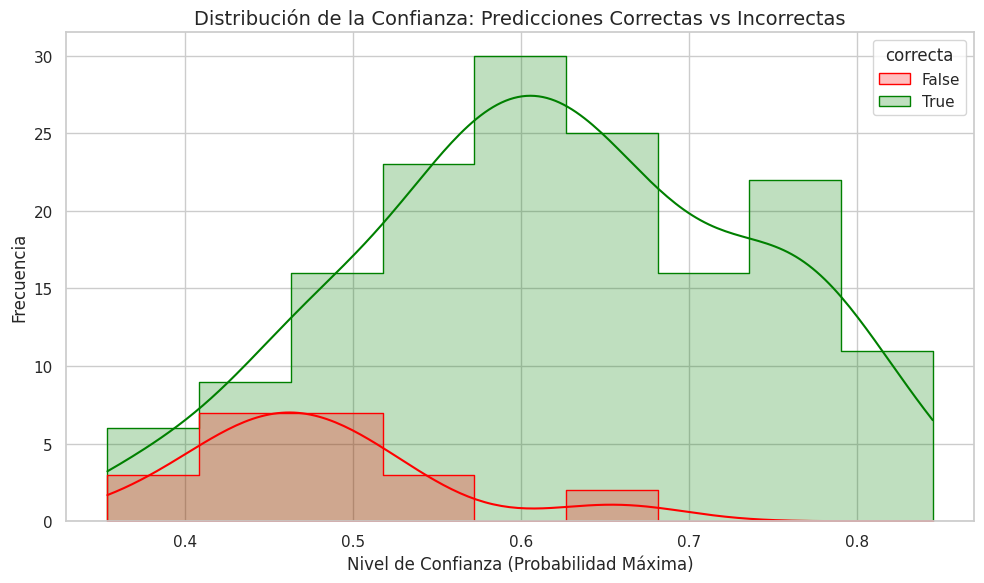

In [ ]:
#Se obtienen las probabilidades de cada clase
y_proba = pipeline.predict_proba(X_test)
confidencias = [max(p) for p in y_proba]
df_test = pd.DataFrame({'real': y_test, 'pred': y_pred, 'confianza': confidencias})
df_test['correcta'] = df_test['real'] == df_test['pred']

#Visualización de la distribución de confianza
plt.figure(figsize=(10, 6))
sns.histplot(data=df_test, x='confianza', hue='correcta', kde=True,
             element='step', palette={True: 'green', False: 'red'})
plt.title('Distribución de la Confianza: Predicciones Correctas vs Incorrectas', fontsize=14)
plt.xlabel('Nivel de Confianza (Probabilidad Máxima)', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)
plt.tight_layout()
plt.show()

### Exportación del modelo

In [ ]:
MODEL_FILENAME = 'sentiment_model.pkl'

#Se guarda el modelo
with open(MODEL_FILENAME, 'wb') as f:
    pickle.dump(pipeline, f)

#Se muestra confirmación y tamaño del archivo
print(f"Modelo guardado como '{MODEL_FILENAME}'")
print(f"Tamaño: {__import__('os').path.getsize(MODEL_FILENAME):,} bytes")

with open(MODEL_FILENAME, 'rb') as f:
    loaded = pickle.load(f)

#Se descarga el archivo al equipo local
files.download(MODEL_FILENAME)

Modelo guardado como 'sentiment_model.pkl'
Tamaño: 82,973 bytes


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>